# **Sector and Stock Selection**

The sector and stock selection analysis aims to improve portfolio construction by reducing and structuring the investment universe before optimisation. First, stocks are grouped into sectors, and sector selection is performed using average Sharpe ratios to identify 3 sectors which are the best performing sectors and also a diversified set of sectors. Within the selected sectors, stocks are ranked based on their individual Sharpe ratios, and weaker or redundant stocks may be removed using correlation to avoid overlap. This process ensures that only high-quality and representative assets are included. Overall, this step produces a refined and diversified stock pool that improves the efficiency and effectiveness of the subsequent portfolio optimisation.


## **Import Libraries**

In [23]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All libraries has been loaded successfully.")

All libraries has been loaded successfully.


## **Sector Selection**

In [24]:
def calculate_sector_avg_sharpe(file_name):
    df = pd.read_csv(file_name).drop(columns=["Date"])

    # Equal-weighted daily sector return
    returns = df.mean(axis=1, skipna=True)

    if len(returns.dropna()) == 0:
        return np.nan

    mean_return = returns.mean()
    volatility = returns.std()

    if volatility == 0:
        sharpe = 0
    else:
        sharpe = (mean_return / volatility) * np.sqrt(252)  # annualised

    return sharpe

In [25]:
sector_files = {
    "Technology": "Technology.csv",
    "Healthcare": "Healthcare.csv",
    "Financial Services": "Financial_Services.csv",
    "Industrials": "Industrials.csv",
    "Energy": "Energy.csv",
    "Basic Materials": "Basic_Materials.csv",
    "Utilities": "Utilities.csv",
    "Real Estate": "Real_Estate.csv",
    "Communication Services": "Communication_Services.csv",
    "Consumer Cyclical": "Consumer_Cyclical.csv",
    "Consumer Defensive": "Consumer_Defensive.csv",
    "Unknown": "Unknown.csv"
}

sector_avg_sharpe = {}

for sector, file_name in sector_files.items():
    sector_avg_sharpe[sector] = calculate_sector_avg_sharpe(file_name)

sector_df = pd.DataFrame(
    list(sector_avg_sharpe.items()),
    columns=["Sector", "Avg_Sharpe"]
)

sector_df = sector_df.sort_values(by="Avg_Sharpe", ascending=False)

print(sector_df)

                    Sector  Avg_Sharpe
10      Consumer Defensive    1.221422
8   Communication Services    1.148318
1               Healthcare    1.133481
0               Technology    0.972114
9        Consumer Cyclical    0.880274
6                Utilities    0.856121
7              Real Estate    0.839477
3              Industrials    0.838032
2       Financial Services    0.736128
5          Basic Materials    0.639732
11                 Unknown    0.567798
4                   Energy    0.207456


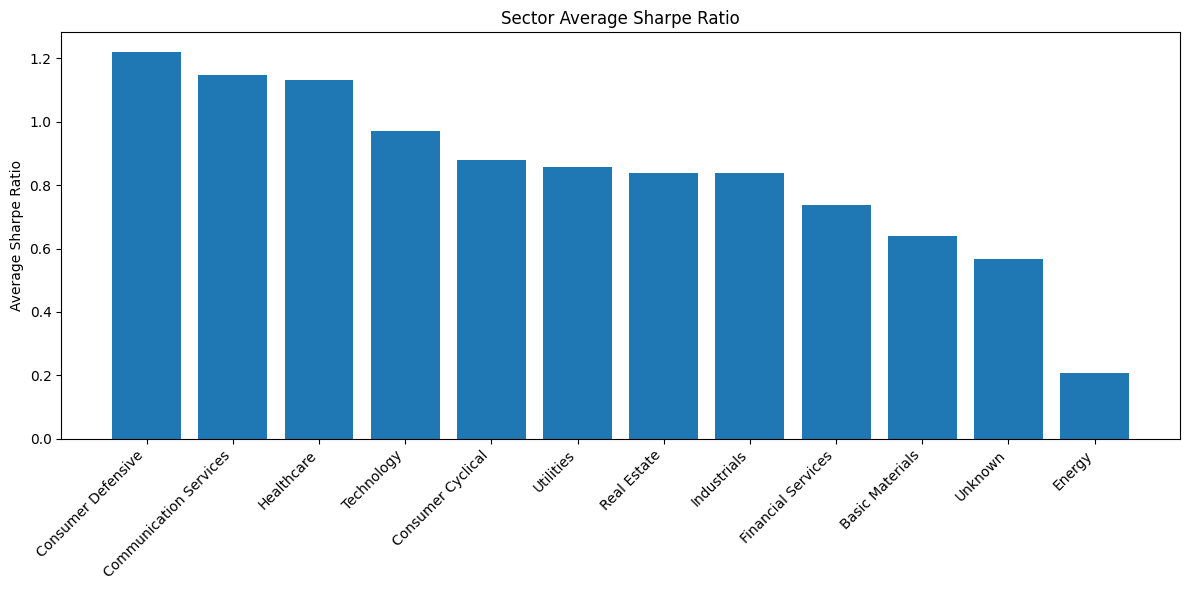

In [26]:
plt.figure(figsize=(12,6))

plt.bar(sector_df["Sector"], sector_df["Avg_Sharpe"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Sharpe Ratio")
plt.title("Sector Average Sharpe Ratio")

plt.tight_layout()
plt.show()

In [27]:
top_sectors = sector_df.sort_values(by="Avg_Sharpe", ascending=False).head(3)

print(top_sectors)

                    Sector  Avg_Sharpe
10      Consumer Defensive    1.221422
8   Communication Services    1.148318
1               Healthcare    1.133481


In [28]:
def calculate_sharpe(file_name):
    df = pd.read_csv(file_name).drop(columns=["Date"])

    stocks_sharpe = {}

    # Compute Sharpe Ratio for each stock
    for stock in df.columns:
        returns = df[stock].dropna()

        if len(returns) == 0:
            continue

        mean_return = returns.mean()
        volatility = returns.std()

        if volatility == 0:
            sharpe = 0
        else:
            sharpe = (mean_return / volatility) * np.sqrt(252)  # annualised

        stocks_sharpe[stock] = sharpe
    
    return stocks_sharpe

sector1 = calculate_sharpe("Consumer_defensive.csv")
sector2 = calculate_sharpe("Communication_services.csv")
sector3 = calculate_sharpe("Healthcare.csv")

sector1_sorted = dict(sorted(sector1.items(), key=lambda x: x[1], reverse=True))
sector2_sorted = dict(sorted(sector2.items(), key=lambda x: x[1], reverse=True))
sector3_sorted = dict(sorted(sector3.items(), key=lambda x: x[1], reverse=True))

In [29]:
def plot_sharpe_bar(sharpe_dict, title):
    stocks = list(sharpe_dict.keys())
    sharpe_values = list(sharpe_dict.values())

    plt.figure(figsize=(15, 6))
    plt.bar(stocks, sharpe_values)

    plt.title(title)
    plt.xlabel("Stocks")
    plt.ylabel("Sharpe Ratio")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

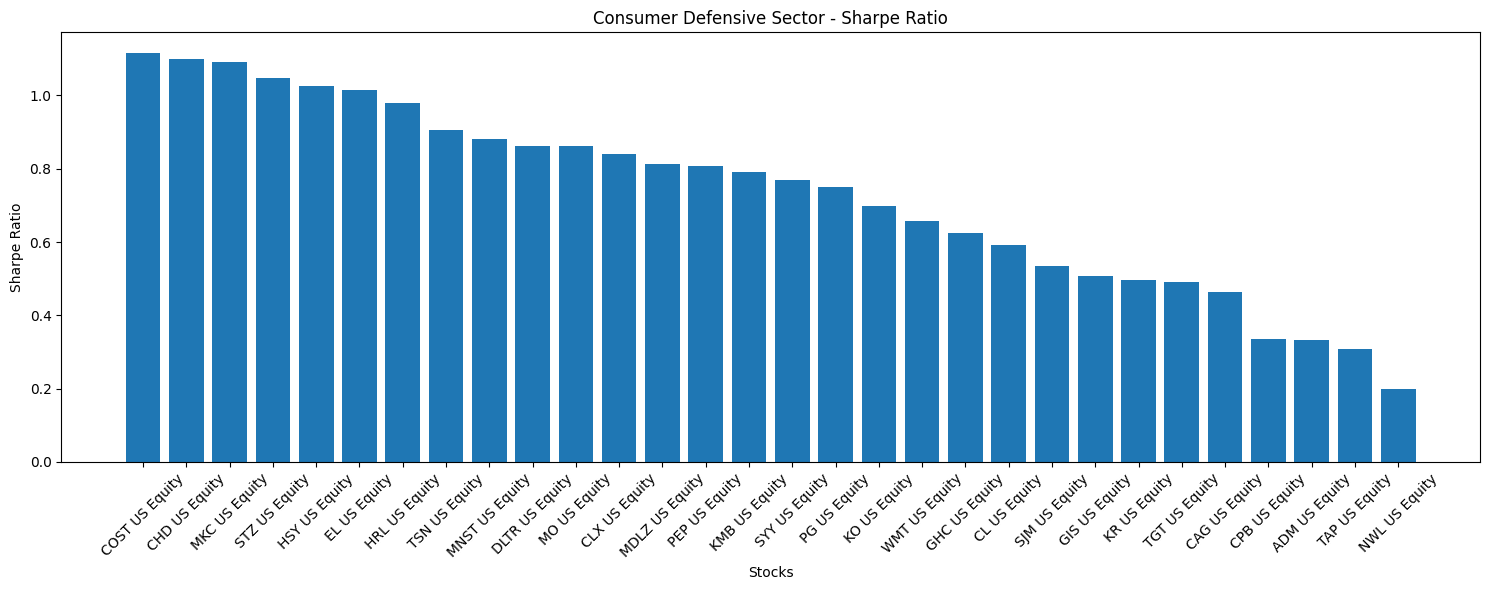

In [30]:
plot_sharpe_bar(sector1_sorted, "Consumer Defensive Sector - Sharpe Ratio")

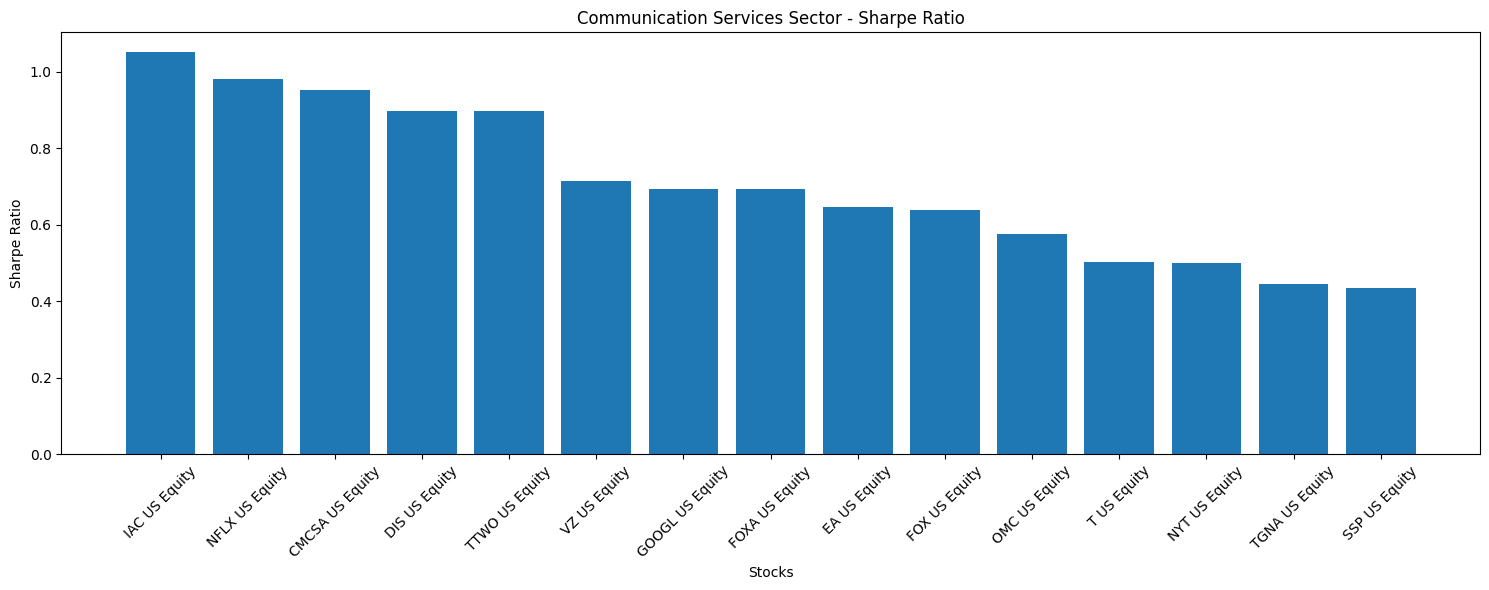

In [31]:
plot_sharpe_bar(sector2_sorted, "Communication Services Sector - Sharpe Ratio")

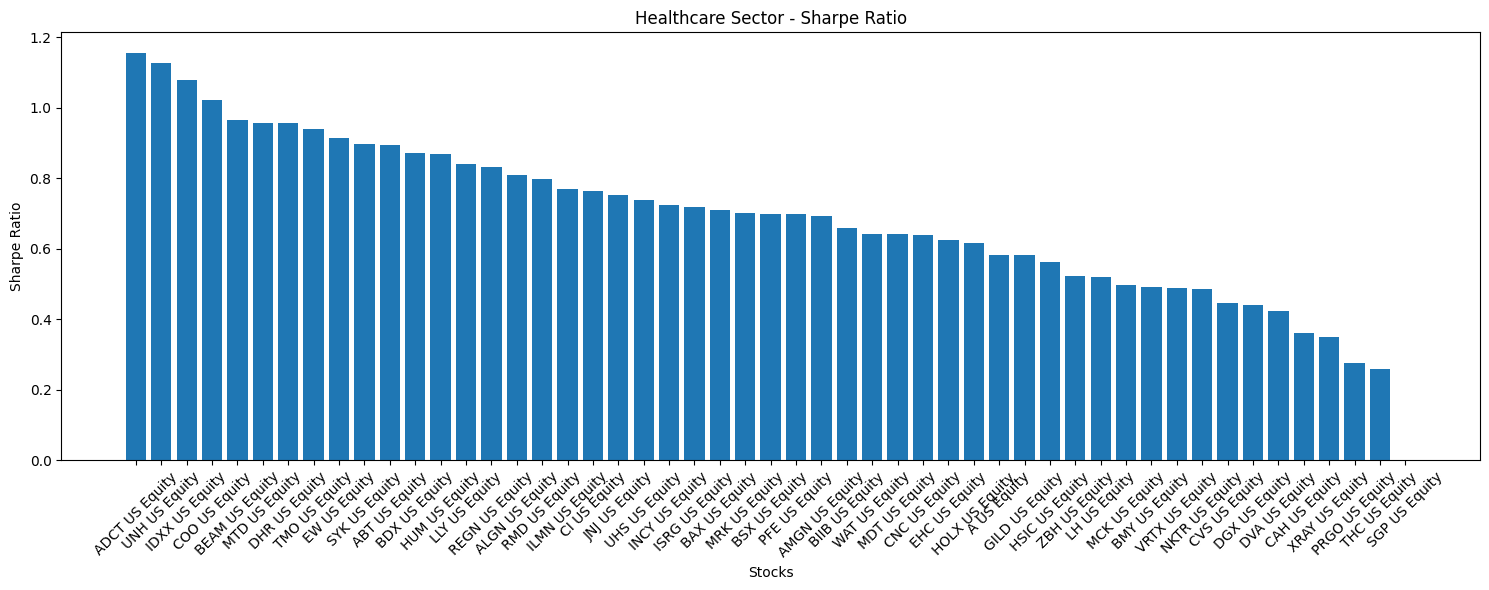

In [32]:
plot_sharpe_bar(sector3_sorted, "Healthcare Sector - Sharpe Ratio")